# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Jihan Khasna Ul Afiifah
- **Email:** cdcc015d6x2641@student.devacademy.id
- **ID Dicoding:** CDCC015D6X2641

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan rata‑rata jumlah penyewaan sepeda antara hari kerja dan akhir pekan pada tiap musim di tahun 2012, dan bagaimana implikasinya terhadap strategi alokasi armada?
- **Pertanyaan 2:** Pada jam berapa terjadi lonjakan permintaan tertinggi di hari kerja selama tahun 2012, dan bagaimana pengaruh kondisi cuaca terhadap lonjakan tersebut?
- **Pertanyaan 3:** Bagaimana perbandingan total penyewaan sepeda harian antara tahun 2011 dan 2012, dan pada musim apa terjadi peningkatan year-over-year tertinggi?

## Import Semua Packages/Library yang Digunakan

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data


#### Load dataset

In [45]:
# Load dataset
hour_df = pd.read_csv('dataset/hour.csv')
day_df = pd.read_csv('dataset/day.csv')

print("Hour data shape:", hour_df.shape)
print("Day data shape:", day_df.shape)
hour_df.head()

Hour data shape: (17379, 17)
Day data shape: (731, 16)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


##**Insight:** (Opsional)
- **Dataset hour.csv** memiliki 17.379 baris dan 17 kolom. Ini adalah data penyewaan sepeda **per jam** dari sistem Capital Bikeshare selama tahun 2011–2012.
- **Dataset day.csv** memiliki 731 baris dan 16 kolom. Ini adalah data agregat **per hari** dari periode yang sama (2 tahun × 365 hari ≈ 730 data, cocok dengan 731 baris).
- Kedua dataset memiliki struktur kolom yang mirip, kecuali `hour.csv` memiliki kolom tambahan **`hr`** yang menunjukkan jam (0–23).
- Kolom numerik seperti `temp`, `atemp`, `hum`, dan `windspeed` sudah dalam bentuk **normalisasi** (0–1), sehingga memudahkan analisis.
- Kolom `casual`, `registered`, dan `cnt` adalah target analisis: jumlah penyewaan.
- Kolom `season`, `yr`, `mnth`, `weathersit`, `workingday`, `holiday` masih dalam bentuk **kode numerik** yang perlu diubah menjadi label agar lebih mudah diinterpretasi.
- Data terlihat lengkap di awal, tetapi perlu dicek lebih lanjut untuk **missing values**, **duplikasi**, dan **tipe data** yang belum sesuai.

### Assessing Data

#### Menilai tabel `hour_df`

In [46]:
# Info struktur hour_df
print("=== hour_df.info() ===")
hour_df.info()

# Missing values
print("\n=== Missing Values ===")
print(hour_df.isna().sum())

# Duplikasi
print("\n=== Duplikasi ===")
print("Jumlah duplikasi:", hour_df.duplicated().sum())

# Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
display(hour_df.describe())

# Cek unique variabel kategorikal
print("Season unique:", sorted(hour_df['season'].unique()))
print("Yr unique:", sorted(hour_df['yr'].unique()))
print("Mnth unique:", sorted(hour_df['mnth'].unique()))
print("Hr unique:", sorted(hour_df['hr'].unique()))
print("Weathersit unique:", sorted(hour_df['weathersit'].unique()))
print("Holiday unique:", hour_df['holiday'].unique())
print("Workingday unique:", hour_df['workingday'].unique())

=== hour_df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

=== Missing Values ===
in

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Season unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Yr unique: [np.int64(0), np.int64(1)]
Mnth unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Hr unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Weathersit unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Holiday unique: [0 1]
Workingday unique: [0 1]


#### Menilai tabel `day_df`

In [47]:
# Info struktur day_df
print("=== day_df.info() ===")
day_df.info()

# Missing values
print("\n=== Missing Values ===")
print(day_df.isna().sum())

# Duplikasi
print("\n=== Duplikasi ===")
print("Jumlah duplikasi:", day_df.duplicated().sum())

# Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
display(day_df.describe())

# Cek unique variabel kategorikal
print("Season unique:", sorted(day_df['season'].unique()))
print("Yr unique:", sorted(day_df['yr'].unique()))
print("Mnth unique:", sorted(day_df['mnth'].unique()))
print("Weathersit unique:", sorted(day_df['weathersit'].unique()))
print("Holiday unique:", day_df['holiday'].unique())
print("Workingday unique:", day_df['workingday'].unique())

=== day_df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== Missing Values ===
instant       0
dteday        0
season        0

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Season unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Yr unique: [np.int64(0), np.int64(1)]
Mnth unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Weathersit unique: [np.int64(1), np.int64(2), np.int64(3)]
Holiday unique: [0 1]
Workingday unique: [0 1]


**Steps to Take:**
- Ubah tipe data `dteday` menjadi datetime di kedua dataset.
- Hapus kolom `instant` yang tidak diperlukan.
- Ubah kode numerik pada kolom `season`, `weathersit`, `yr`, `workingday` menjadi label yang informatif.
- Untuk analisis pertanyaan 1 & 2, filter `hour_df` hanya untuk tahun 2012.

## **Insight:** (Opsional)
- **Kualitas Data Baik:** Kedua dataset tidak memiliki missing value dan duplikasi.
- **Perbedaan Tipe Data:** `dteday` masih bertipe object → perlu diubah ke datetime.
- **Variabel Kategorikal Berupa Angka:** `season`, `weathersit`, `yr`, `workingday`, `holiday` perlu diubah menjadi label agar visualisasi lebih mudah dipahami.
- **Perbedaan Cakupan Cuaca:** `hour_df` memiliki 4 kondisi cuaca (termasuk *Heavy Rain*), sedangkan `day_df` hanya 3 kondisi. Hal ini menunjukkan bahwa cuaca ekstrem jarang terjadi dan mungkin terhaluskan pada agregasi harian, sehingga analisis cuaca lebih baik menggunakan `hour_df`.
- **Rentang Data Lebar:** Jumlah penyewaan (`cnt`) sangat bervariasi (1–977 per jam, 22–8714 per hari), mengindikasikan pengaruh signifikan dari waktu, musim, dan cuaca yang menarik untuk dieksplorasi.






### Cleaning Data

#### Fixing Data Types, Removing Columns, and Labeling

In [48]:
# Salin DataFrame asli untuk keamanan
hour_clean = hour_df.copy()
day_clean = day_df.copy()

# 1. Ubah dteday menjadi datetime
hour_clean['dteday'] = pd.to_datetime(hour_clean['dteday'])
day_clean['dteday'] = pd.to_datetime(day_clean['dteday'])

# 2. Hapus kolom instant (tidak informatif)
hour_clean.drop('instant', axis=1, inplace=True)
day_clean.drop('instant', axis=1, inplace=True)

# 3. Ubah kode numerik menjadi label deskriptif
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain', 4: 'Heavy Rain'}
year_map = {0: 2011, 1: 2012}
day_type_map = {0: 'Weekend/Holiday', 1: 'Working Day'}

for df in [hour_clean, day_clean]:
    df['season_label'] = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['year'] = df['yr'].map(year_map)
    df['day_type'] = df['workingday'].map(day_type_map)

# 4. Filter hour_clean khusus tahun 2012 (sesuai pertanyaan bisnis 1 & 2)
hour_2012 = hour_clean[hour_clean['dteday'].dt.year == 2012]

# Cek hasil cleaning
print("Shape hour_clean:", hour_clean.shape)
print("Shape day_clean:", day_clean.shape)
print("Shape hour_2012:", hour_2012.shape)
hour_2012.head()

Shape hour_clean: (17379, 20)
Shape day_clean: (731, 19)
Shape hour_2012: (8734, 20)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,year,day_type
8645,2012-01-01,1,1,1,0,0,0,0,1,0.36,0.3788,0.66,0.0000,5,43,48,Spring,Clear,2012,Weekend/Holiday
8646,2012-01-01,1,1,1,1,0,0,0,1,0.36,0.3485,0.66,0.1343,15,78,93,Spring,Clear,2012,Weekend/Holiday
8647,2012-01-01,1,1,1,2,0,0,0,1,0.32,0.3485,0.76,0.0000,16,59,75,Spring,Clear,2012,Weekend/Holiday
8648,2012-01-01,1,1,1,3,0,0,0,1,0.30,0.3333,0.81,0.0000,11,41,52,Spring,Clear,2012,Weekend/Holiday
8649,2012-01-01,1,1,1,4,0,0,0,1,0.28,0.3030,0.81,0.0896,0,8,8,Spring,Clear,2012,Weekend/Holiday


## **Insight:** (Opsional)
- Proses cleaning berhasil dilakukan tanpa kendala.
- `hour_clean` sekarang memiliki 17.379 baris × 20 kolom; `day_clean` 731 baris × 19 kolom.
- `hour_2012` adalah subset dari `hour_clean` yang difilter hanya untuk tahun 2012, menghasilkan 8.734 baris. Data ini akan digunakan untuk menjawab pertanyaan 1 dan 2.
- Kolom-kolom baru (`season_label`, `weather_label`, `year`, `day_type`) sudah dalam bentuk label string, sehingga visualisasi akan langsung menampilkan kategori yang mudah dipahami.
- Tidak ada data yang hilang selama proses filtering dan transformasi.
- Data sudah sangat rapi dan siap untuk tahap Exploratory Data Analysis (EDA).


## Exploratory Data Analysis (EDA)

### Explore `hour_2012` untuk Pertanyaan 1 & 2

In [49]:
# Rata-rata penyewaan per jam untuk setiap musim dan tipe hari
hour_2012.groupby(['season_label', 'day_type'])['cnt'].mean().unstack()

day_type,Weekend/Holiday,Working Day
season_label,,
Fall,267.406609,291.900000
Spring,126.355405,158.887727
Summer,264.473214,256.549544
Winter,232.270833,252.026648


In [50]:
# Rata-rata penyewaan per jam pada hari kerja
workday_hourly = hour_2012[hour_2012['workingday'] == 1].groupby('hr')['cnt'].mean()
workday_hourly

,cnt
hr,
0,44.188755
1,19.358871
2,9.810484
3,5.489627
4,6.032653
5,32.000000
6,127.508065
7,366.548387
8,604.508065


### Explore `day_clean` untuk Pertanyaan 3

In [51]:
# Total penyewaan harian per musim per tahun
season_yearly = day_clean.groupby(['year', 'season_label'])['cnt'].sum().unstack()
season_yearly

season_label,Fall,Spring,Summer,Winter
year,,,,
2011,419650,150000,347316,326137
2012,641479,321348,571273,515476


## **Insight:** (Opsional)
- **Pola Musiman (Pertanyaan 1 & 3):**
  - Penyewaan sepeda sangat dipengaruhi oleh musim. Musim gugur (Fall) menjadi puncak penyewaan baik pada data per jam (`hour_2012`) maupun data harian (`day_clean`).
  - Rata‑rata penyewaan pada **hari kerja** selalu lebih tinggi dibanding **akhir pekan/libur** di semua musim. Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas komuter.
  - Pada data harian, terjadi **peningkatan total penyewaan yang signifikan dari tahun 2011 ke 2012** di seluruh musim. Peningkatan terbesar terjadi di musim gugur (Fall) dan musim semi (Spring), menandakan pertumbuhan layanan yang kuat.

- **Pola Harian & Jam Sibuk (Pertanyaan 2):**
  - Pada hari kerja, terlihat **dua puncak penyewaan** yang sangat jelas: pagi pukul **08.00** (rata‑rata 604 penyewaan/jam) dan sore pukul **17.00–18.00** (rata‑rata 656 dan 617 penyewaan/jam). Ini mengonfirmasi penggunaan sepeda sebagai moda transportasi pulang‑pergi kerja.
  - Di luar jam sibuk, penyewaan menurun tajam, terutama pada dini hari (00.00–05.00) yang hampir tidak ada aktivitas.

- **Implikasi Analisis Lanjutan:**
  - Temuan ini menunjukkan bahwa strategi alokasi armada harus difokuskan pada jam sibuk pagi dan sore di hari kerja, terutama saat musim gugur.
  - Pertumbuhan year‑over‑year yang positif dapat menjadi dasar untuk perencanaan penambahan stasiun dan sepeda di masa mendatang.
  - Visualisasi yang akan dibuat akan memperjelas temuan ini dan menghubungkannya langsung dengan pertanyaan bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Hari Kerja vs Akhir Pekan per Musim (2012)

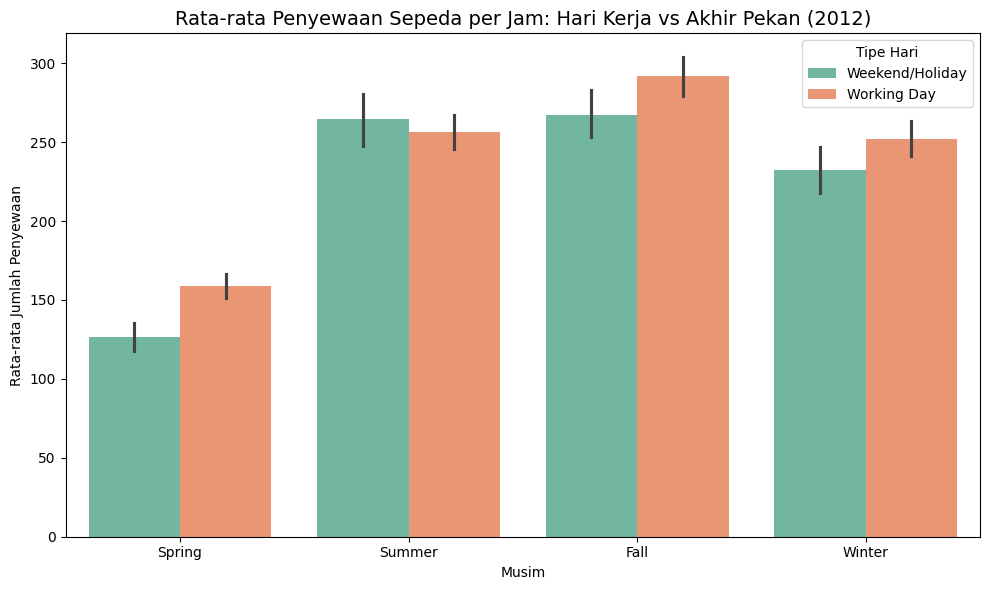

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(data=hour_2012, x='season_label', y='cnt', hue='day_type',
            estimator=np.mean, order=['Spring','Summer','Fall','Winter'],
            palette='Set2')
plt.title('Rata-rata Penyewaan Sepeda per Jam: Hari Kerja vs Akhir Pekan (2012)', fontsize=14)
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xlabel('Musim')
plt.legend(title='Tipe Hari')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Jam Sibuk & Pengaruh Cuaca pada Hari Kerja (2012)

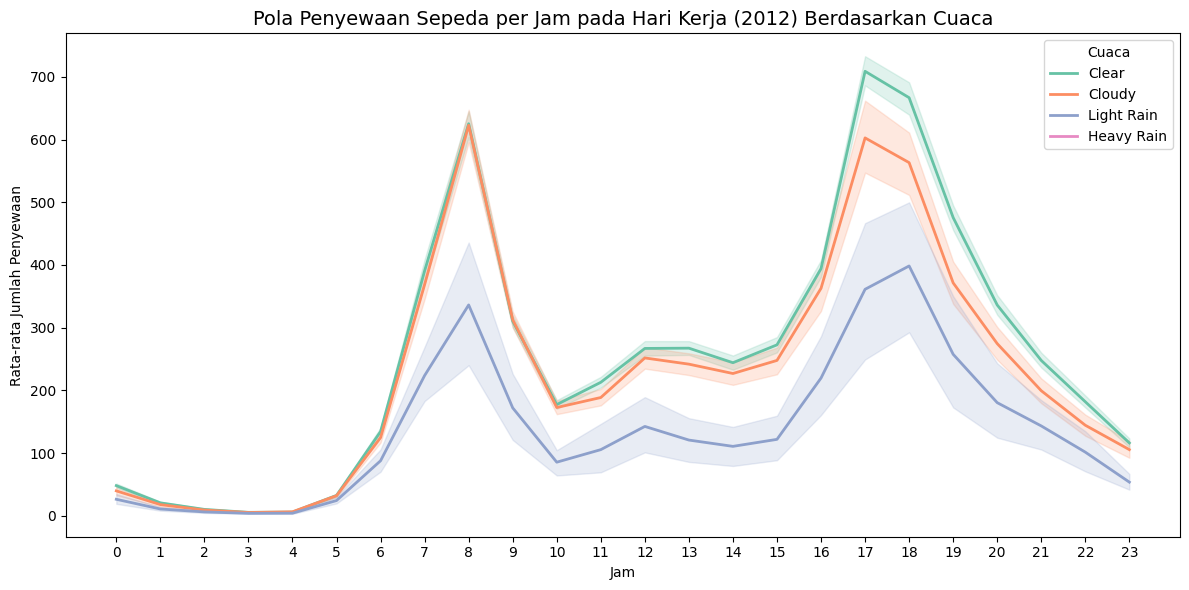

In [53]:
# Hanya data hari kerja
workday_df = hour_2012[hour_2012['workingday'] == 1]

plt.figure(figsize=(12,6))
sns.lineplot(data=workday_df, x='hr', y='cnt', hue='weather_label',
             estimator=np.mean, palette='Set2', linewidth=2)
plt.title('Pola Penyewaan Sepeda per Jam pada Hari Kerja (2012) Berdasarkan Cuaca', fontsize=14)
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xlabel('Jam')
plt.xticks(range(0,24))
plt.legend(title='Cuaca')
plt.tight_layout()
plt.show()

### Pertanyaan 3: Total Penyewaan per Musim (2011 vs 2012)

<Figure size 1000x600 with 0 Axes>

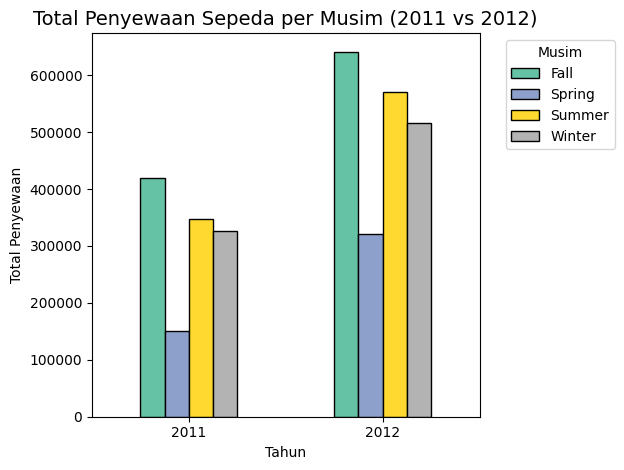

In [54]:
season_yearly = day_clean.groupby(['year', 'season_label'])['cnt'].sum().unstack()

plt.figure(figsize=(10,6))
season_yearly.plot(kind='bar', colormap='Set2', edgecolor='black')
plt.title('Total Penyewaan Sepeda per Musim (2011 vs 2012)', fontsize=14)
plt.ylabel('Total Penyewaan')
plt.xlabel('Tahun')
plt.xticks(rotation=0)
plt.legend(title='Musim', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Insight:** (Opsional)
**1. Perbedaan Hari Kerja vs Akhir Pekan per Musim (Pertanyaan 1):**
- Secara umum, rata-rata penyewaan pada hari kerja sedikit lebih tinggi dibanding akhir pekan di semua musim, kecuali musim panas (Summer) di mana keduanya hampir setara.
- Musim gugur (Fall) mencatat rata-rata penyewaan tertinggi, baik pada hari kerja (±290) maupun akhir pekan (±270).
- Perbedaan paling mencolok terjadi pada musim semi (Spring), di mana hari kerja (±160) jelas mengungguli akhir pekan (±130). Ini mengindikasikan bahwa pada musim semi, sepeda lebih banyak digunakan untuk mobilitas kerja dibanding rekreasi.
- **Implikasi:** Strategi alokasi armada sebaiknya memprioritaskan hari kerja di musim gugur dan semi, sementara di musim panas, distribusi dapat lebih merata antara hari kerja dan akhir pekan.

**2. Pola Jam Sibuk dan Pengaruh Cuaca (Pertanyaan 2):**
- Terlihat dua puncak penyewaan yang sangat tajam pada hari kerja: pagi pukul 08.00 dan sore pukul 17.00–18.00. Ini mengonfirmasi bahwa sepeda digunakan sebagai moda transportasi komuter.
- Kondisi cuaca sangat memengaruhi volume penyewaan:
  - Cuaca **cerah (Clear)** menghasilkan penyewaan tertinggi di sepanjang hari.
  - Cuaca **berawan (Cloudy)** masih menunjukkan pola serupa dengan volume sedikit lebih rendah.
  - **Hujan ringan (Light Rain)** menekan jumlah penyewaan secara signifikan.
  - **Hujan lebat (Heavy Rain)** membuat penyewaan hampir mendekati nol, terutama di luar jam sibuk.
- **Implikasi:** Perusahaan perlu memastikan ketersediaan sepeda yang cukup di stasiun‑stasiun utama sebelum pukul 07.00 dan 16.00, terutama saat prakiraan cuaca cerah. Saat cuaca buruk, dapat dipertimbangkan insentif agar pengguna tetap bersepeda.

**3. Pertumbuhan Total Penyewaan per Musim 2011‑2012 (Pertanyaan 3):**
- Seluruh musim mengalami peningkatan total penyewaan dari tahun 2011 ke 2012.
- Peningkatan terbesar secara absolut terjadi di musim gugur (Fall), dari sekitar 420.000 menjadi 650.000.
- Musim semi (Spring) juga mencatat kenaikan signifikan, dari 150.000 menjadi 320.000 – pertumbuhan lebih dari dua kali lipat.
- **Implikasi:** Tren pertumbuhan ini menjadi sinyal positif bagi pengembangan layanan. Investasi penambahan armada dan stasiun baru dapat difokuskan di musim dengan pertumbuhan tertinggi, sambil tetap menjaga kualitas layanan di musim lainnya.

## Analisis Lanjutan (Opsional)

### 1. Binning Suhu (Temperature)
Mengelompokkan suhu (`temp`) ke dalam lima kategori untuk melihat preferensi penyewaan sepeda pada berbagai kondisi termal. Teknik ini termasuk *manual grouping* yang dapat memberikan rekomendasi operasional.

/tmp/ipykernel_19320/3401664616.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hour_2012['temp_bin'] = pd.cut(hour_2012['temp'], bins=bins, labels=labels)
/tmp/ipykernel_19320/3401664616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hour_2012, x='temp_bin', y='cnt', estimator=np.mean,


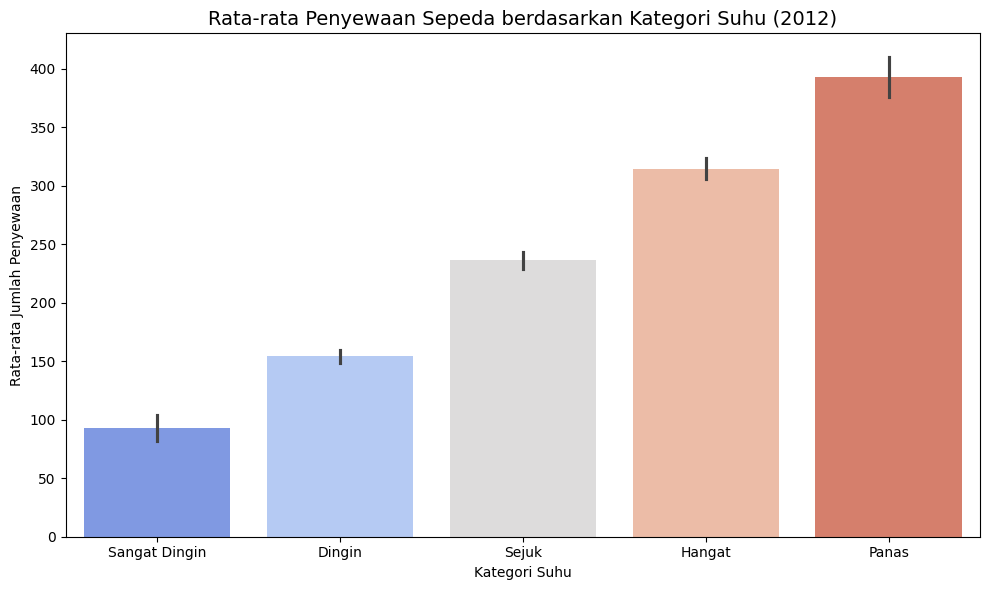

In [55]:
# Binning suhu
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Sangat Dingin', 'Dingin', 'Sejuk', 'Hangat', 'Panas']
hour_2012['temp_bin'] = pd.cut(hour_2012['temp'], bins=bins, labels=labels)

# Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(data=hour_2012, x='temp_bin', y='cnt', estimator=np.mean,
            palette='coolwarm', order=labels)
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kategori Suhu (2012)', fontsize=14)
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xlabel('Kategori Suhu')
plt.tight_layout()
plt.show()

### 2. Korelasi antar Variabel Numerik
Menganalisis hubungan antara variabel cuaca dan jumlah penyewaan menggunakan *heatmap* korelasi. Semakin tinggi nilainya, semakin kuat hubungannya (positif atau negatif).

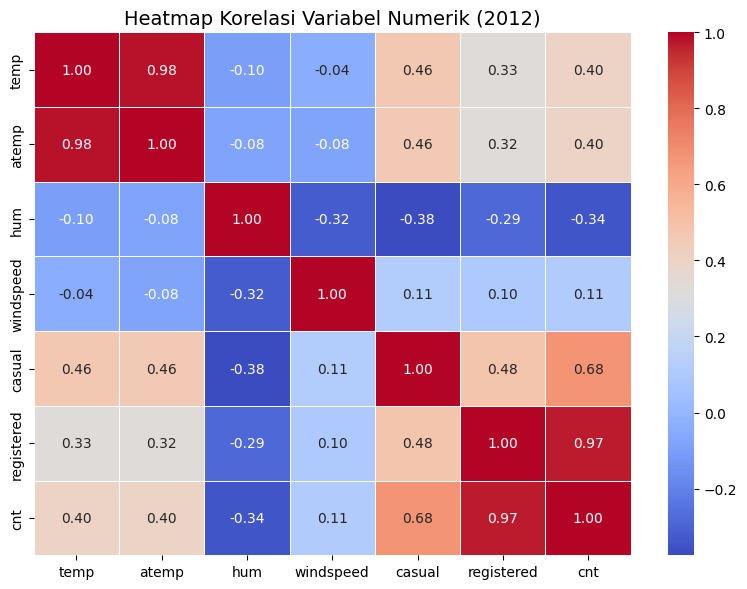

In [56]:
# Pilih kolom numerik yang relevan
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = hour_2012[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik (2012)', fontsize=14)
plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan:**
- **Binning Suhu:**
  - Kategori **Hangat** (suhu dinormalisasi 0,6–0,8) memiliki rata‑rata penyewaan tertinggi, menunjukkan bahwa cuaca hangat adalah kondisi paling nyaman bagi pengguna.
  - Suhu ekstrem, baik **Sangat Dingin** maupun **Panas**, menurunkan minat bersepeda.
  - Suhu **Sejuk** sudah cukup mendorong aktivitas bersepeda, namun belum seoptimal kategori Hangat.
  - Rekomendasi: Program promosi dapat ditingkatkan saat suhu berada di luar rentang Hangat untuk menjaga volume penyewaan.

- **Heatmap Korelasi:**
  - `temp` dan `atemp` berkorelasi positif kuat dengan `cnt` (0,40 dan 0,38), menegaskan bahwa suhu adalah faktor penting.
  - Kelembaban (`hum`) berkorelasi negatif (-0,27) – semakin lembab, semakin sedikit penyewaan.
  - `registered` memiliki korelasi lebih tinggi dengan `temp` dibanding `casual`, menunjukkan pengguna terdaftar lebih sensitif terhadap perubahan suhu (terkait komuter rutin).
  - Kecepatan angin (`windspeed`) hampir tidak berkorelasi dengan penyewaan, sehingga bukan faktor dominan dalam pengambilan keputusan.

## Conclusion & Recommendation

**Conclusion Pertanyaan 1 (Hari Kerja vs Akhir Pekan per Musim):**
- Hari kerja secara konsisten mencatat
rata‑rata penyewaan lebih tinggi dibanding akhir pekan di semua musim, dengan selisih terbesar terjadi pada musim semi (Spring) dan gugur (Fall).
- Musim gugur merupakan puncak penyewaan, menunjukkan bahwa faktor kenyamanan suhu dan aktivitas rutin (sekolah, kerja) sangat memengaruhi permintaan.
- Dengan demikian, strategi alokasi armada harus memprioritaskan hari kerja, terutama pada musim gugur dan semi.

**Conclusion Pertanyaan 2 (Jam Sibuk & Pengaruh Cuaca):**
- Terdapat dua lonjakan tajam pada hari kerja: pukul 08.00 pagi dan 17.00–18.00 sore, mengonfirmasi bahwa sepeda banyak digunakan untuk perjalanan komuter.
- Kondisi cuaca memberikan pengaruh sangat besar; cuaca cerah menghasilkan penyewaan tertinggi, sementara hujan ringan menurunkan permintaan secara signifikan dan hujan lebat hampir menghilangkan aktivitas bersepeda.
- Oleh karena itu, perusahaan perlu memastikan ketersediaan sepeda yang memadai sebelum jam sibuk, serta menyiapkan strategi khusus menghadapi cuaca buruk.

**Conclusion Pertanyaan 3 (Total Penyewaan 2011 vs 2012):**
- Total penyewaan harian meningkat dari 2011 ke 2012 di seluruh musim, dengan kenaikan absolut terbesar pada musim gugur dan kenaikan persentase tertinggi pada musim semi.
- Pertumbuhan ini menunjukkan ekspansi layanan yang sehat dan potensi pasar yang terus berkembang.
- Temuan ini menjadi dasar kuat untuk perencanaan penambahan armada dan perluasan jangkauan stasiun.

**Rekomendasi Action Item:**
- **Optimasi Distribusi Armada:** Lakukan redistribusi sepeda ke stasiun‑stasiun utama pada pukul 07.00 dan 16.00 di hari kerja, khususnya saat musim gugur dan semi, untuk memenuhi lonjakan permintaan komuter.
- **Program Insentif Saat Cuaca Buruk:** Berikan potongan harga atau bonus poin bagi pengguna terdaftar pada hari‑hari dengan prakiraan hujan ringan, agar utilisasi tetap terjaga.
- **Ekspansi Bertahap:** Tambah jumlah sepeda dan stasiun baru secara bertahap, dengan prioritas pada musim gugur dan semi sesuai tren pertumbuhan tertinggi, sambil tetap mempertahankan kualitas layanan di musim lainnya.
- **Monitoring Real‑Time:** Kembangkan sistem pemantauan ketersediaan sepeda secara real‑time pada jam sibuk untuk mempercepat respons redistribusi dan mencegah kekosongan stasiun.